In [1]:
import os

os.environ["NJ_DOMAIN"] = "v3"  # must precede the nj_sfincs import

import sys
from datetime import datetime
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "nj_sfincs").is_dir())
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "scripts"))

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyproj
import xarray as xr
from matplotlib.patches import Rectangle
from scipy.spatial import cKDTree

from nj_sfincs import domain
from nj_sfincs.config import BaseConfig

DOM = domain.active()
BASE_RES = BaseConfig().base_res

PROBE = ROOT / "data" / "probe_mesh_v3" / "domain_dryrun.npz"
_p = np.load(PROBE)
FX, FY, FZ, FM = _p["x"], _p["y"], _p["z"], _p["mask"]
ACT, BC, OUTF = FM > 0, FM == 2, FM == 3

REGION = gpd.read_file(DOM.region).to_crs(DOM.epsg)
TR = pyproj.Transformer.from_crs("EPSG:4326", f"EPSG:{DOM.epsg}", always_xy=True)

print(f"domain {DOM.name}  building={DOM.building}  epsg={DOM.epsg}  "
      f"base_res={BASE_RES} m  mask_zmin={DOM.mask_zmin} m")
print(f"probe  {PROBE.relative_to(ROOT)}  ({PROBE.stat().st_size / 1e6:.0f} MB)")
print(f"faces  {len(FM):,}   active {ACT.sum():,}   "
      f"water-level BC {BC.sum():,}   free-outflow {OUTF.sum():,}")
print(f"ring   {DOM.region.name}")

domain v3  building=True  epsg=32618  base_res=200 m  mask_zmin=-10.0 m
probe  data/probe_mesh_v3/domain_dryrun.npz  (82 MB)
faces  3,267,861   active 1,659,778   water-level BC 6,835   free-outflow 1,664
ring   region_v3_EDITED_inland.geojson


In [2]:
C_ACT, C_BC, C_OUT, C_RING = "#cfe3f5", "#eb6834", "#c0392b", "#52514e"
ARM_C = {"ocean": "#eb6834", "ocean_south": "#e0a83b",
         "narrows": "#7a4fd6", "arthur_kill": "#2a9d5c"}


def km_axes(ax):
    ax.set_aspect("equal")
    ax.xaxis.set_major_formatter(lambda v, _: f"{v / 1000:.0f}")
    ax.yaxis.set_major_formatter(lambda v, _: f"{v / 1000:.0f}")
    ax.tick_params(labelsize=8)
    ax.grid(alpha=0.25, lw=0.5)


def draw_ring(ax, lw=0.9, color=C_RING, zorder=6):
    REGION.boundary.plot(ax=ax, color=color, lw=lw, zorder=zorder)


def active_bg(ax, color=C_ACT):
    g, ext = binned(FX[ACT], FY[ACT], np.ones(int(ACT.sum())), BASE_RES, how="count")
    ax.imshow(np.where(g > 0, 1.0, np.nan), extent=ext, origin="lower",
              cmap=plt.matplotlib.colors.ListedColormap([color]),
              interpolation="nearest", zorder=1)


def full_extent(ax):
    ax.set_xlim(FX.min() - 5000, FX.max() + 5000)
    ax.set_ylim(FY.min() - 5000, FY.max() + 5000)


def binned(x, y, v, res, how="max"):
    """Rasterise face values onto a regular `res`-metre grid. Points must be pre-clipped."""
    x0, y0 = x.min(), y.min()
    nx = int(np.ceil((x.max() - x0) / res)) + 1
    ny = int(np.ceil((y.max() - y0) / res)) + 1
    ix = np.clip(((x - x0) / res).astype(int), 0, nx - 1)
    iy = np.clip(((y - y0) / res).astype(int), 0, ny - 1)
    ext = (x0, x0 + nx * res, y0, y0 + ny * res)
    if how == "count":
        g = np.zeros((ny, nx))
        np.add.at(g, (iy, ix), 1)
        return g, ext
    g = np.full((ny, nx), -np.inf if how == "max" else np.inf)
    (np.maximum.at if how == "max" else np.minimum.at)(g, (iy, ix), v)
    g[~np.isfinite(g)] = np.nan
    return g, ext


def break_gaps(s, tol=3.0):
    """NaN across sampling gaps so a line breaks instead of spanning a clipped stretch."""
    if len(s) < 3:
        return s
    d = s.index.to_series().diff()
    step = d.median()
    brk = s.index[d > tol * step]
    return s if not len(brk) else pd.concat(
        [s, pd.Series(np.nan, index=brk - step)]).sort_index()


ARMS = {a.name: a for a in DOM.boundary_arms}


def arm_of(x, y):
    """Which declared arm box each cell falls in ('' = none)."""
    out = np.full(len(x), "", dtype=object)
    for a in DOM.boundary_arms:
        xmin, ymin, xmax, ymax = a.box
        sel = (x > xmin) & (x < xmax) & (y > ymin) & (y < ymax) & (out == "")
        out[sel] = a.name
    return out


BC_X, BC_Y, BC_Z = FX[BC], FY[BC], FZ[BC]
BC_ARM = arm_of(BC_X, BC_Y)

# Face size = distance to the nearest neighbouring face centre, snapped (in log space)
# to the quadtree ladder 200/100/50/25 m. Used to size markers and to map refinement.
LADDER = np.array([BASE_RES / 2 ** k for k in range(4)])
_nn = cKDTree(np.c_[FX, FY]).query(np.c_[FX, FY], k=2, workers=-1)[0][:, 1]
SIZE = LADDER[np.abs(np.log(_nn[:, None] / LADDER[None, :])).argmin(axis=1)]

import rasterio

with rasterio.open(ROOT / "data" / "elevation_v3" / "bed_v3_coarse_25m.tif") as _b:
    _z = _b.read(1).astype("float32")
    _z[_z == _b.nodata] = np.nan
    _z = np.nanmean(_z[: _z.shape[0] // 4 * 4, : _z.shape[1] // 4 * 4]
                    .reshape(_z.shape[0] // 4, 4, _z.shape[1] // 4, 4), axis=(1, 3))
    _cx = _b.transform.c + (np.arange(_z.shape[1]) + 0.5) * _b.res[0] * 4
    _cy = _b.transform.f - (np.arange(_z.shape[0]) + 0.5) * _b.res[1] * 4


def coastline(ax, lw=0.5):
    """The 0 m NAVD88 line of the merged bed, at 100 m — where the shore is."""
    ax.contour(_cx, _cy, _z, levels=[0.0], colors="#1f1f1f", linewidths=lw, zorder=3)

In [3]:
from build_naccs_boundary import (
    DEFAULT_MAX_DIST,
    DEFAULT_MIN_DEPTH,
    DRY,
    PAD_START,
    PAD_STOP,
    read_zips,
)

pts = read_zips(use_cache=True)
TIMES = pts.pop("_times")
SP = sorted(k for k in pts if isinstance(k, int))
sp_lon = np.array([pts[i]["lon"] for i in SP])
sp_lat = np.array([pts[i]["lat"] for i in SP])
sp_dep = np.array([pts[i]["depth"] for i in SP])
sp_x, sp_y = TR.transform(sp_lon, sp_lat)

tt = np.array([datetime.strptime(str(s), "%Y%m%d%H%M") for s in TIMES])
win = (tt >= PAD_START) & (tt <= PAD_STOP)
sp_wet = np.array([np.all(np.asarray(pts[i]["wl"], float)[win] > DRY) for i in SP])

# distance every save point <-> every forced cell (6,835 x 1,321)
D = np.hypot(BC_X[:, None] - sp_x[None, :], BC_Y[:, None] - sp_y[None, :])
near = D.min(axis=0)      # per save point: metres to the nearest forced cell
gap_all = D.min(axis=1)   # per forced cell: metres to the nearest save point

in_range = near <= DEFAULT_MAX_DIST
# v3 sets open_coast_max_y = None, so the open-coast depth screen applies EVERYWHERE,
# including the Delaware Bay wedge and the Cape May Canal mouth.
deep = sp_dep >= DEFAULT_MIN_DEPTH
keep = in_range & sp_wet & deep

print(f"save points          {len(SP):,}")
print(f"within {DEFAULT_MAX_DIST:.0f} m of a forced cell   {int(in_range.sum()):,}")
print(f"  dropped, dry in {PAD_START:%m-%d}..{PAD_STOP:%m-%d}   "
      f"{int((in_range & ~sp_wet).sum()):,}")
print(f"  dropped, depth < {DEFAULT_MIN_DEPTH:.0f} m       "
      f"{int((in_range & sp_wet & ~deep).sum()):,}")
print(f"KEPT as boundary support   {int(keep.sum()):,}")

[read] cache hit — 1321 save points from _sandy_parsed.npz


save points          1,321
within 2000 m of a forced cell   406
  dropped, dry in 10-24..11-01   67
  dropped, depth < 8 m       149
KEPT as boundary support   190


In [4]:
import csv

from build_naccs_boundary import _vdatum
from check_naccs_vs_sensors import MIN_NODE_DEPTH_M, _m

CREST = (pd.Timestamp("2012-10-29 12:00"), pd.Timestamp("2012-10-30 12:00"))

# NACCS is MSL(1992); every observation here is NAVD88. VDatum's `contiguous` region
# returns no t_z south of ~Barnegat, so the southern nodes fall back to the nearest NOAA
# station's published MSL-NAVD88 separation (mdapi datums.json, ft -> m).
# ⚠️ Fallback values are NEVER written to data/NACCS/vdatum_lmsl_navd88.csv.
VD_CSV = ROOT / "data" / "NACCS" / "vdatum_lmsl_navd88.csv"
_vd = ({int(r["sp_id"]): float(r["offset_navd88_m"])
        for r in csv.DictReader(VD_CSV.open())} if VD_CSV.exists() else {})
NOAA_PLANE = {  # id: (lon, lat, MSL height in NAVD88 [m])
    8518750: (-74.0141, 40.7006, -0.20 * 0.3048),
    8531680: (-74.0092, 40.4669, -0.24 * 0.3048),
    8534720: (-74.4181, 39.3553, -0.40 * 0.3048),
    8536110: (-74.9600, 38.9683, -0.45 * 0.3048),
}


def msl_to_navd88(sp):
    if sp in _vd and np.isfinite(_vd[sp]):
        return _vd[sp], "vdatum"
    lon, lat = pts[sp]["lon"], pts[sp]["lat"]
    off = _vdatum(lon, lat)
    if np.isfinite(off):
        _vd[sp] = off
        return off, "vdatum"
    sid = min(NOAA_PLANE, key=lambda s: _m(lat, lon, NOAA_PLANE[s][1], NOAA_PLANE[s][0]))
    return NOAA_PLANE[sid][2], f"noaa {sid}"


NIDX = pd.to_datetime([datetime.strptime(str(t), "%Y%m%d%H%M") for t in TIMES])


def node_series(sp):
    off, src = msl_to_navd88(sp)
    w = np.asarray(pts[sp]["wl"], float)
    return pd.Series(np.where(w > DRY, w + off, np.nan), index=NIDX), off, src


GAUGE_FILES = [
    ("NOAA", "gtsm/noaa_sandy_validation.nc", "waterlevel"),
    ("USGS tidal", "gtsm/usgs_sandy_tidal_v3.nc", "waterlevel"),
    ("STN raritan", "gtsm/sandy_storm_tide_raritan.nc", "stormtide_m"),
    ("STN nj", "gtsm/sandy_storm_tide_nj.nc", "stormtide_m"),
    ("STN south", "gtsm/sandy_storm_tide_south.nc", "stormtide_m"),
]

GAUGES = []
for src, rel, var in GAUGE_FILES:
    ds = xr.open_dataset(ROOT / "data" / rel)
    t = pd.to_datetime(ds["time"].values)
    for k, sid in enumerate(ds["stations"].values):
        obs = pd.Series(ds[var].values[:, k], index=t).dropna()
        if obs.empty:
            continue
        GAUGES.append(dict(source=src, station=str(int(sid)),
                           lon=float(ds["lon"].values[k]), lat=float(ds["lat"].values[k]),
                           obs=obs))
print(f"{len(GAUGES)} observed water-level records inside the v3 bbox")

# a node must be deep enough AND never dry through the padded window — the nearest
# node to NOAA Cape May (7549) is 4 m deep and dry for 1,877 samples
WETN = [p for p in SP if pts[p]["depth"] >= MIN_NODE_DEPTH_M
        and np.all(np.asarray(pts[p]["wl"], float)[win] > DRY)]
act_tree = cKDTree(np.c_[FX[ACT], FY[ACT]])
act_z = FZ[ACT]
RING_GEOM = REGION.geometry.union_all()

rows, panels = [], []
for g in GAUGES:
    gx, gy = TR.transform(g["lon"], g["lat"])
    dact, iact = act_tree.query([gx, gy])
    sp = min(WETN, key=lambda p: _m(g["lat"], g["lon"], pts[p]["lat"], pts[p]["lon"]))
    dist = _m(g["lat"], g["lon"], pts[sp]["lat"], pts[sp]["lon"])
    mod, off, dsrc = node_series(sp)
    obs = g["obs"]
    both = pd.concat([obs.rename("obs"),
                      mod.reindex(obs.index.union(mod.index)).interpolate("time")
                         .rename("mod")], axis=1, sort=True).loc[obs.index].dropna()
    if both.empty:
        continue
    crest = both.loc[CREST[0]:CREST[1]]
    pk_o = crest["obs"].max() if not crest.empty else np.nan
    pk_m = crest["mod"].max() if not crest.empty else np.nan
    lag = ((crest["mod"].idxmax() - crest["obs"].idxmax()).total_seconds() / 60
           if not crest.empty else np.nan)
    rows.append(dict(
        source=g["source"], station=g["station"], lat=round(g["lat"], 3),
        lon=round(g["lon"], 3),
        in_ring=RING_GEOM.contains(gpd.points_from_xy([gx], [gy])[0]),
        d_active_m=round(float(dact)),
        bed_m=round(float(act_z[iact]), 2),
        node=sp, node_km=round(dist / 1000, 2), node_depth_m=round(pts[sp]["depth"], 1),
        datum=dsrc, datum_off_m=round(off, 3),
        n=len(both), obs_h=round((obs.index[-1] - obs.index[0]).total_seconds() / 3600),
        first_is_max=bool(obs.idxmax() == obs.index[0]),
        bias_m=round(float((both["mod"] - both["obs"]).mean()), 3),
        rmse_m=round(float(np.sqrt(((both["mod"] - both["obs"]) ** 2).mean())), 3),
        peak_obs=round(float(pk_o), 3), peak_mod=round(float(pk_m), 3),
        peak_err=round(float(pk_m - pk_o), 3),
        lag_min=round(float(lag)) if np.isfinite(lag) else np.nan,
    ))
    panels.append((g, both, sp, dist, dsrc))
GM = pd.DataFrame(rows).sort_values("lat", ascending=False)

33 observed water-level records inside the v3 bbox


   !! VDatum failed at (-74.9599,38.9679): 't_z'


   !! VDatum failed at (-74.4746,39.4103): 't_z'
   !! VDatum failed at (-74.4508,39.3611): 't_z'
   !! VDatum failed at (-74.4263,39.3769): 't_z'
   !! VDatum failed at (-74.5735,39.2880): 't_z'


   !! VDatum failed at (-74.6985,39.1613): 't_z'
   !! VDatum failed at (-74.7458,39.1075): 't_z'
   !! VDatum failed at (-74.7650,39.0567): 't_z'
   !! VDatum failed at (-74.8917,38.9483): 't_z'


   !! VDatum failed at (-74.8963,39.1622): 't_z'


   !! VDatum failed at (-74.6118,39.2942): 't_z'
   !! VDatum failed at (-74.8644,38.9374): 't_z'
   !! VDatum failed at (-74.8644,38.9374): 't_z'


## Boundary — forced cells by arm and the NACCS points that force them

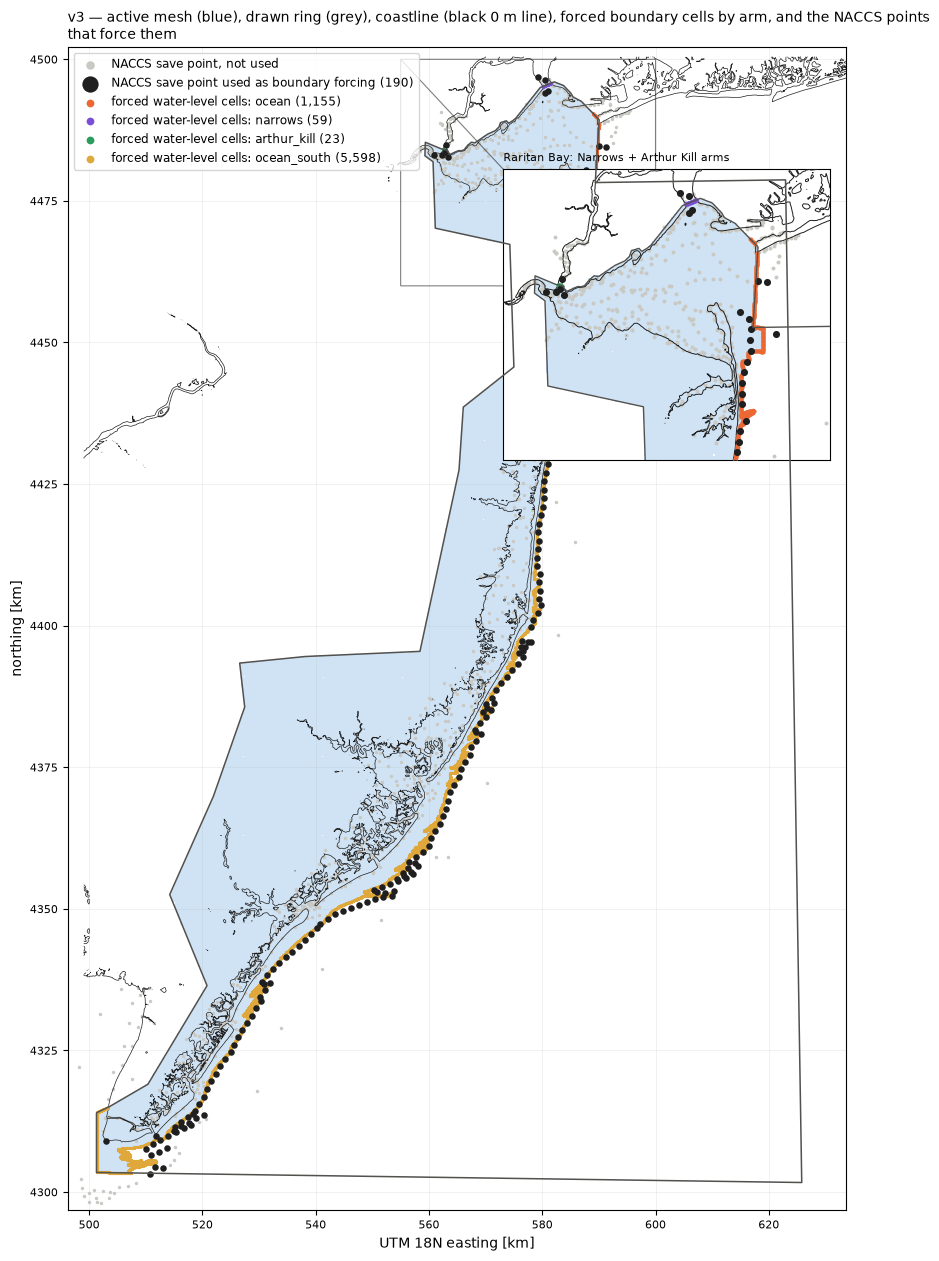

In [5]:
fig, ax = plt.subplots(figsize=(10, 12.5), constrained_layout=True)
active_bg(ax)
ax.scatter(sp_x, sp_y, s=6, c="#c9c8c2", lw=0, zorder=2, label="NACCS save point, not used")
ax.scatter(sp_x[keep], sp_y[keep], s=22, c="#1f1f1f", lw=0, zorder=5,
           label=f"NACCS save point used as boundary forcing ({int(keep.sum())})")
for a in DOM.boundary_arms:
    sel = BC_ARM == a.name
    ax.scatter(BC_X[sel], BC_Y[sel], s=5, c=ARM_C[a.name], lw=0, zorder=4,
               label=f"forced water-level cells: {a.name} ({int(sel.sum()):,})")
coastline(ax)
draw_ring(ax, lw=1.1)
km_axes(ax)
full_extent(ax)
ax.legend(fontsize=8.5, loc="upper left", markerscale=2.5)
ax.set_title("v3 — active mesh (blue), drawn ring (grey), coastline (black 0 m line), forced boundary cells by arm, "
             "and the NACCS points that force them", fontsize=10, loc="left", wrap=True)
ax.set_xlabel("UTM 18N easting [km]")
ax.set_ylabel("northing [km]")

ins = ax.inset_axes([0.56, 0.60, 0.42, 0.34])
active_bg(ins)
ins.scatter(sp_x, sp_y, s=8, c="#c9c8c2", lw=0, zorder=2)
ins.scatter(sp_x[keep], sp_y[keep], s=26, c="#1f1f1f", lw=0, zorder=5)
for a in DOM.boundary_arms:
    sel = BC_ARM == a.name
    ins.scatter(BC_X[sel], BC_Y[sel], s=7, c=ARM_C[a.name], lw=0, zorder=4)
coastline(ins, lw=0.7)
draw_ring(ins, lw=1.0)
ins.set_xlim(555_000, 600_000)
ins.set_ylim(4_460_000, 4_500_000)
ins.set_aspect("equal")
ins.set_xticks([])
ins.set_yticks([])
ins.set_title("Raritan Bay: Narrows + Arthur Kill arms", fontsize=8, loc="left")
ax.indicate_inset_zoom(ins, edgecolor="k", lw=0.8);

## Quadtree refinement — face size of every active cell

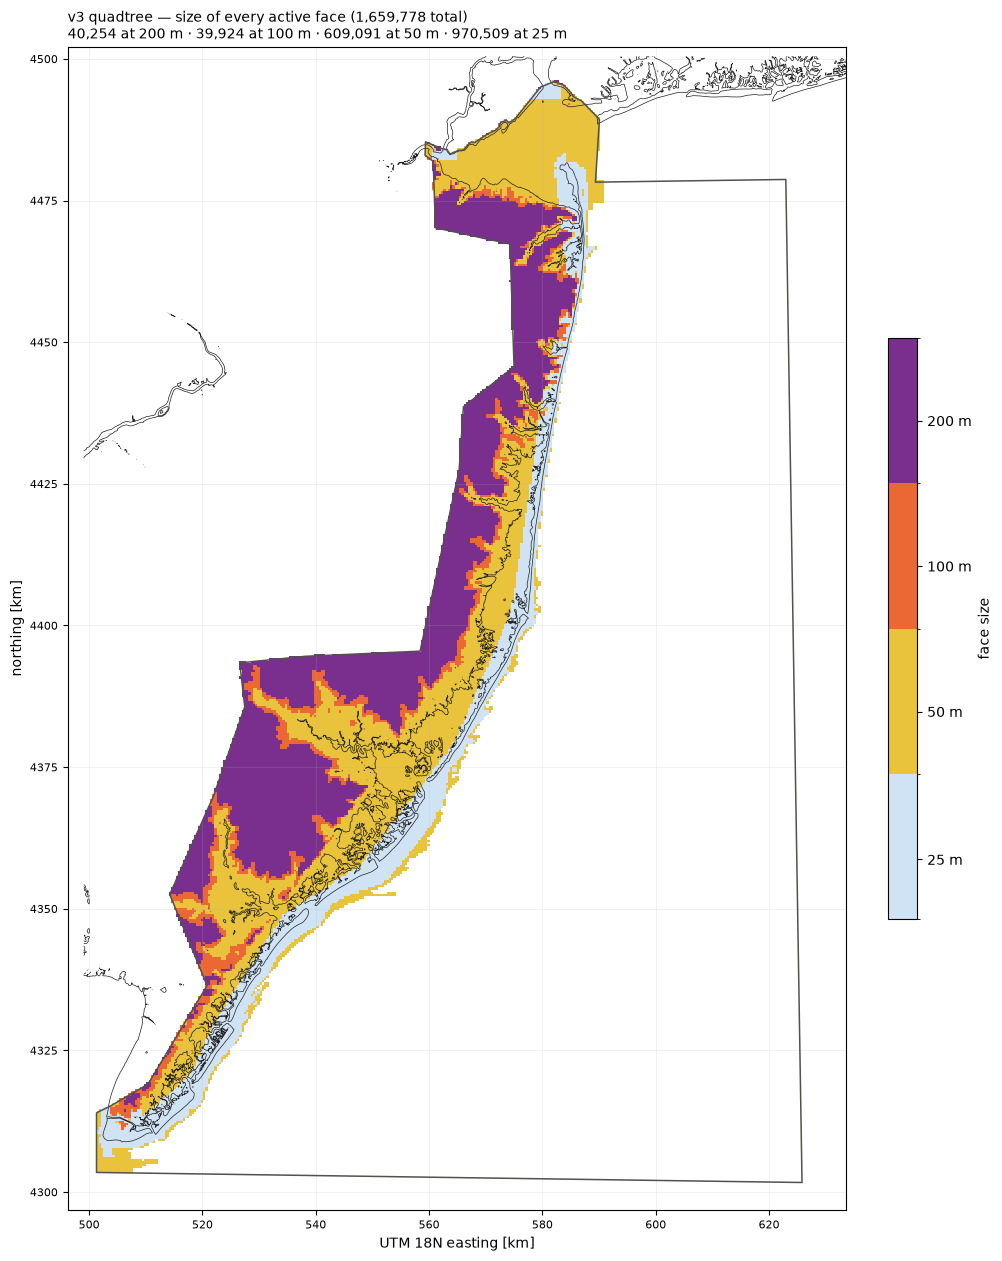

In [6]:
cmap = plt.matplotlib.colors.ListedColormap(["#cfe3f5", "#e8c33b", "#eb6834", "#7a2f8f"])
norm = plt.matplotlib.colors.BoundaryNorm([18, 35, 70, 140, 280], cmap.N)
g, ext = binned(FX[ACT], FY[ACT], SIZE[ACT], 400.0, how="min")

fig, ax = plt.subplots(figsize=(10, 12.5), constrained_layout=True)
im = ax.imshow(g, extent=ext, origin="lower", cmap=cmap, norm=norm,
               interpolation="nearest", zorder=1)
coastline(ax)
draw_ring(ax, lw=1.1)
km_axes(ax)
full_extent(ax)
cb = fig.colorbar(im, ax=ax, shrink=0.5, ticks=LADDER[::-1])
cb.ax.set_yticklabels([f"{s:.0f} m" for s in LADDER[::-1]])
cb.set_label("face size")
counts = " · ".join(f"{int(((SIZE == s) & ACT).sum()):,} at {s:.0f} m" for s in LADDER)
ax.set_title(f"v3 quadtree — size of every active face ({int(ACT.sum()):,} total)\n"
             f"{counts}", fontsize=10, loc="left")
ax.set_xlabel("UTM 18N easting [km]")
ax.set_ylabel("northing [km]");

## Gauges vs the NACCS forcing product

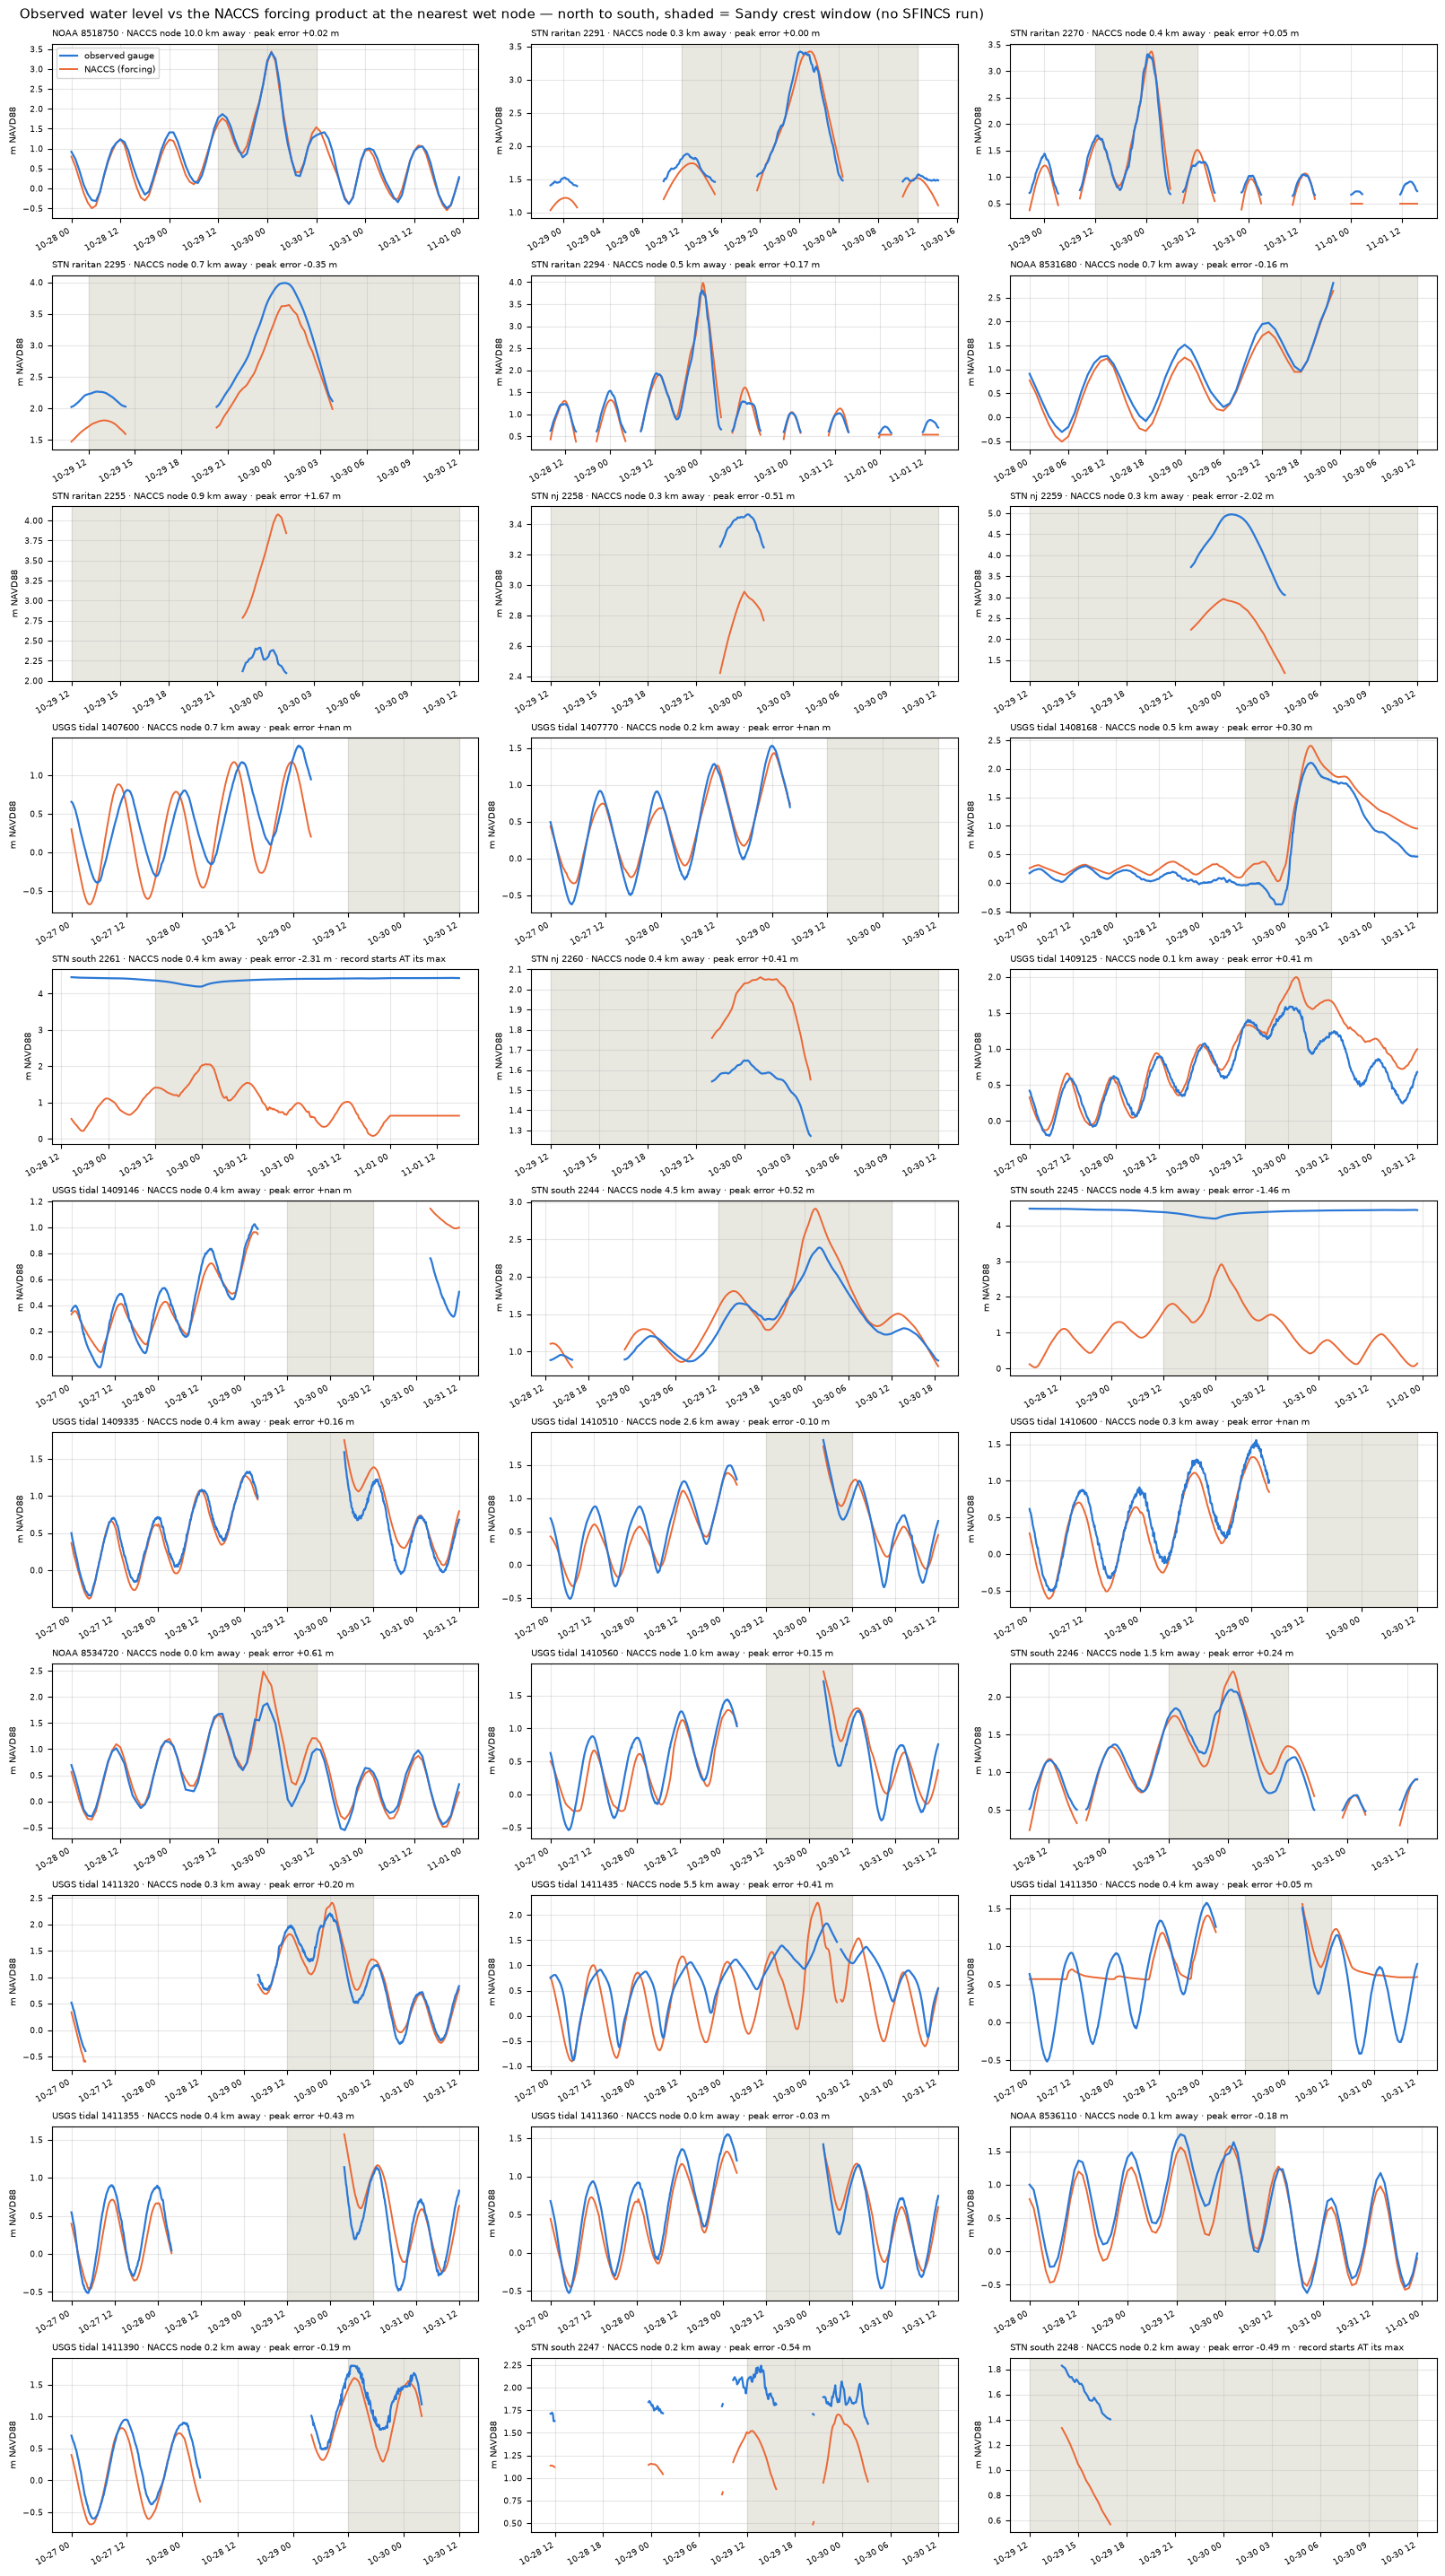

In [7]:
order = np.argsort([-p[0]["lat"] for p in panels])
ncol = 3
nrow = int(np.ceil(len(order) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(16, 2.6 * nrow), constrained_layout=True,
                         squeeze=False)
for ax, k in zip(axes.ravel(), order):
    g, both, sp, dist, dsrc = panels[k]
    r = GM[(GM.source == g["source"]) & (GM.station == g["station"])].iloc[0]
    ob, md = break_gaps(both["obs"]), break_gaps(both["mod"])
    ax.plot(ob.index, ob.values, color="#2a78d6", lw=1.6, label="observed gauge", zorder=5)
    ax.plot(md.index, md.values, color="#eb6834", lw=1.4, label="NACCS (forcing)")
    ax.axvspan(*CREST, color="#e8e7e0", zorder=0)
    ax.set_title(f"{g['source']} {g['station']} · NACCS node {dist / 1000:.1f} km away · "
                 f"peak error {r.peak_err:+.2f} m"
                 + (" · record starts AT its max" if r.first_is_max else ""),
                 fontsize=7.5, loc="left")
    ax.tick_params(labelsize=6.5)
    ax.grid(alpha=0.3)
    ax.set_ylabel("m NAVD88", fontsize=7)
    for lab in ax.get_xticklabels():
        lab.set_rotation(30)
        lab.set_ha("right")
for ax in axes.ravel()[len(order):]:
    ax.axis("off")
axes[0, 0].legend(fontsize=7, loc="upper left")
fig.suptitle("Observed water level vs the NACCS forcing product at the nearest wet node — "
             "north to south, shaded = Sandy crest window (no SFINCS run)",
             fontsize=10.5, x=0.01, ha="left");

## Gauge locations

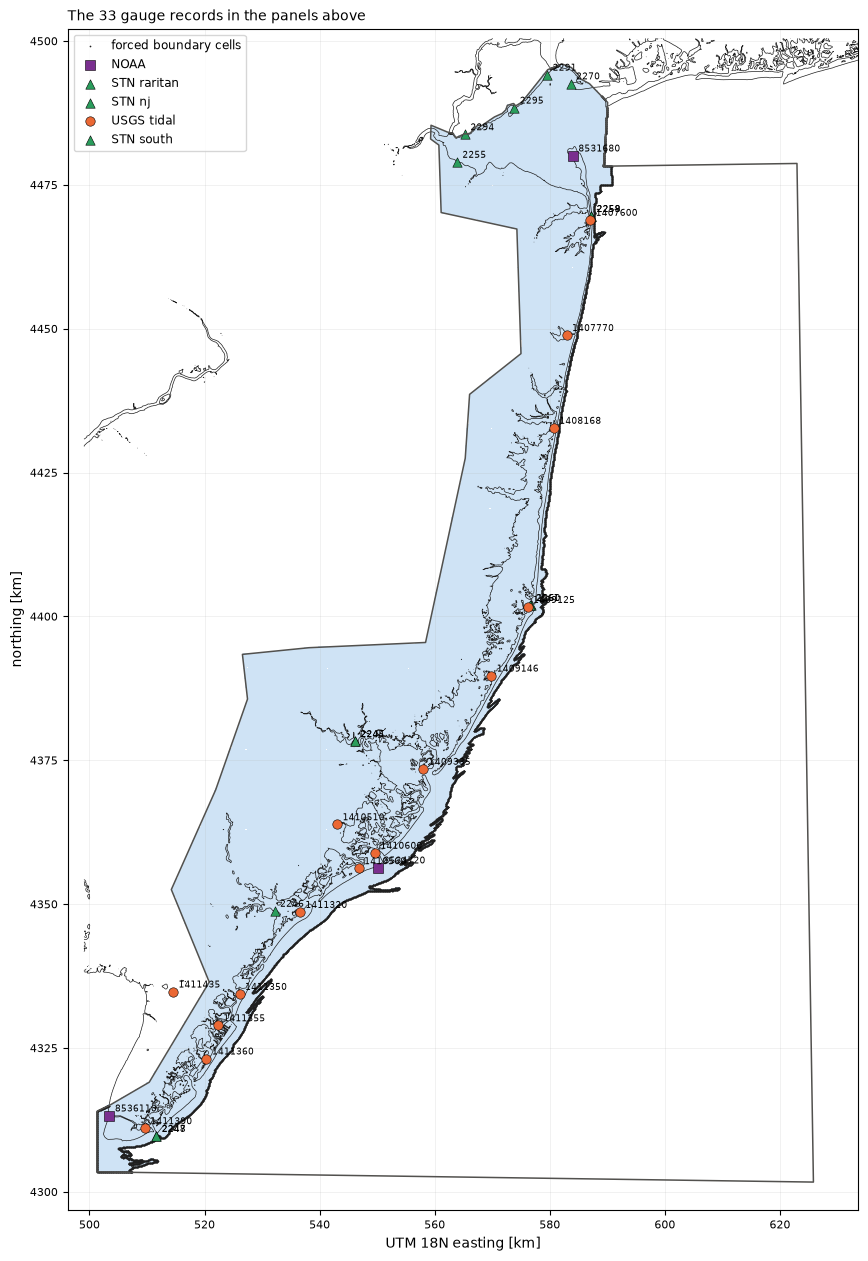

In [8]:
fig, ax = plt.subplots(figsize=(10, 12.5), constrained_layout=True)
active_bg(ax)
ax.scatter(BC_X, BC_Y, s=1.5, c="#1f1f1f", lw=0, zorder=3, label="forced boundary cells")
MK = {"NOAA": "s", "USGS tidal": "o", "STN raritan": "^", "STN nj": "^", "STN south": "^"}
CO = {"NOAA": "#7a2f8f", "USGS tidal": "#eb6834", "STN raritan": "#2a9d5c",
      "STN nj": "#2a9d5c", "STN south": "#2a9d5c"}
seen = set()
for _, r in GM.iterrows():
    gx, gy = TR.transform(r.lon, r.lat)
    ax.scatter([gx], [gy], s=46, marker=MK[r.source], c=CO[r.source], lw=0.4,
               edgecolor="k", zorder=6, label=r.source if r.source not in seen else None)
    seen.add(r.source)
    ax.annotate(r.station, (gx, gy), fontsize=6.5, xytext=(4, 3),
                textcoords="offset points", zorder=7)
coastline(ax)
draw_ring(ax, lw=1.1)
km_axes(ax)
full_extent(ax)
ax.legend(fontsize=8.5, loc="upper left")
ax.set_title(f"The {len(GM)} gauge records in the panels above", fontsize=10, loc="left")
ax.set_xlabel("UTM 18N easting [km]")
ax.set_ylabel("northing [km]");